In [1]:
# Step 1: Install gdown (handles Google Drive links properly)
!pip install gdown -q

import gdown
import pandas as pd

# Step 2: Download from Google Drive
file_id = "1N6V_6G1qTk2Ze6TBWnBK6pGmhlwFgNTE"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "DataCoSupplyChainDataset.csv", quiet=False)

# Step 3: Load it
df = pd.read_csv("DataCoSupplyChainDataset.csv", encoding="ISO-8859-1")

print(f"✅ Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

Downloading...
From: https://drive.google.com/uc?id=1N6V_6G1qTk2Ze6TBWnBK6pGmhlwFgNTE
To: /content/DataCoSupplyChainDataset.csv
100%|██████████| 95.9M/95.9M [00:00<00:00, 248MB/s]


✅ Loaded: 180,519 rows, 53 columns


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [2]:
cols = [
    "Order Country", "Order Region", "Order City",
    "Latitude", "Longitude",
    "Shipping Mode", "Days for shipping (real)",
    "Days for shipment (scheduled)", "Late_delivery_risk",
    "Delivery Status", "Order Status",
    "Sales", "Order Item Quantity",
    "Order Item Profit Ratio", "Category Name"
]

df = df[cols].copy()
df.columns = [
    "country", "region", "city", "lat", "lon",
    "ship_mode", "days_actual", "days_scheduled", "late_risk",
    "delivery_status", "order_status", "sales", "quantity",
    "profit_ratio", "category"
]

print(f"✅ Trimmed: {df.shape}")

✅ Trimmed: (180519, 15)


In [3]:
df["lat"]            = pd.to_numeric(df["lat"], errors="coerce")
df["lon"]            = pd.to_numeric(df["lon"], errors="coerce")
df["sales"]          = pd.to_numeric(df["sales"], errors="coerce")
df["days_actual"]    = pd.to_numeric(df["days_actual"], errors="coerce")
df["days_scheduled"] = pd.to_numeric(df["days_scheduled"], errors="coerce")

df = df.drop_duplicates()
df["lead_time_variance"] = df["days_actual"] - df["days_scheduled"]

print(f"✅ Clean shape: {df.shape}")
print(df.head(3))

✅ Clean shape: (180183, 16)
     country          region     city        lat         lon       ship_mode  \
0  Indonesia  Southeast Asia   Bekasi  18.251453  -66.037056  Standard Class   
1      India      South Asia  Bikaner  18.279451  -66.037064  Standard Class   
2      India      South Asia  Bikaner  37.292233 -121.881279  Standard Class   

   days_actual  days_scheduled  late_risk   delivery_status order_status  \
0            3               4          0  Advance shipping     COMPLETE   
1            5               4          1     Late delivery      PENDING   
2            4               4          0  Shipping on time       CLOSED   

    sales  quantity  profit_ratio        category  lead_time_variance  
0  327.75         1          0.29  Sporting Goods                  -1  
1  327.75         1         -0.80  Sporting Goods                   1  
2  327.75         1         -0.80  Sporting Goods                   0  


In [4]:
# Country risk summary
country_risk = df.groupby("country").agg(
    total_orders     = ("late_risk", "count"),
    late_orders      = ("late_risk", "sum"),
    avg_lead_var     = ("lead_time_variance", "mean"),
    avg_sales        = ("sales", "mean"),
    avg_profit_ratio = ("profit_ratio", "mean")
).reset_index()

country_risk = country_risk[country_risk["total_orders"] >= 30].copy()
country_risk["late_rate"] = country_risk["late_orders"] / country_risk["total_orders"]

print("=== Top 10 Riskiest Countries ===")
print(country_risk.sort_values("late_rate", ascending=False).head(10).to_string(index=False))

=== Top 10 Riskiest Countries ===
             country  total_orders  late_orders  avg_lead_var  avg_sales  avg_profit_ratio  late_rate
               Gabón            45           35      1.111111 205.644004          0.020889   0.777778
               Túnez            36           28      0.861111 173.846392          0.160833   0.777778
        Turkmenistán            53           37      0.679245 228.459250          0.023208   0.698113
          Costa Rica            36           25      1.305556 165.199169          0.033889   0.694444
            Moldavia            78           54      1.410256 196.808978          0.066410   0.692308
Bosnia y Herzegovina            45           31      0.688889 197.090892         -0.039556   0.688889
             Georgia            92           63      0.619565 196.718156          0.051739   0.684783
              Yibuti            31           21      0.612903 211.915166          0.255161   0.677419
             Ecuador           294          197 

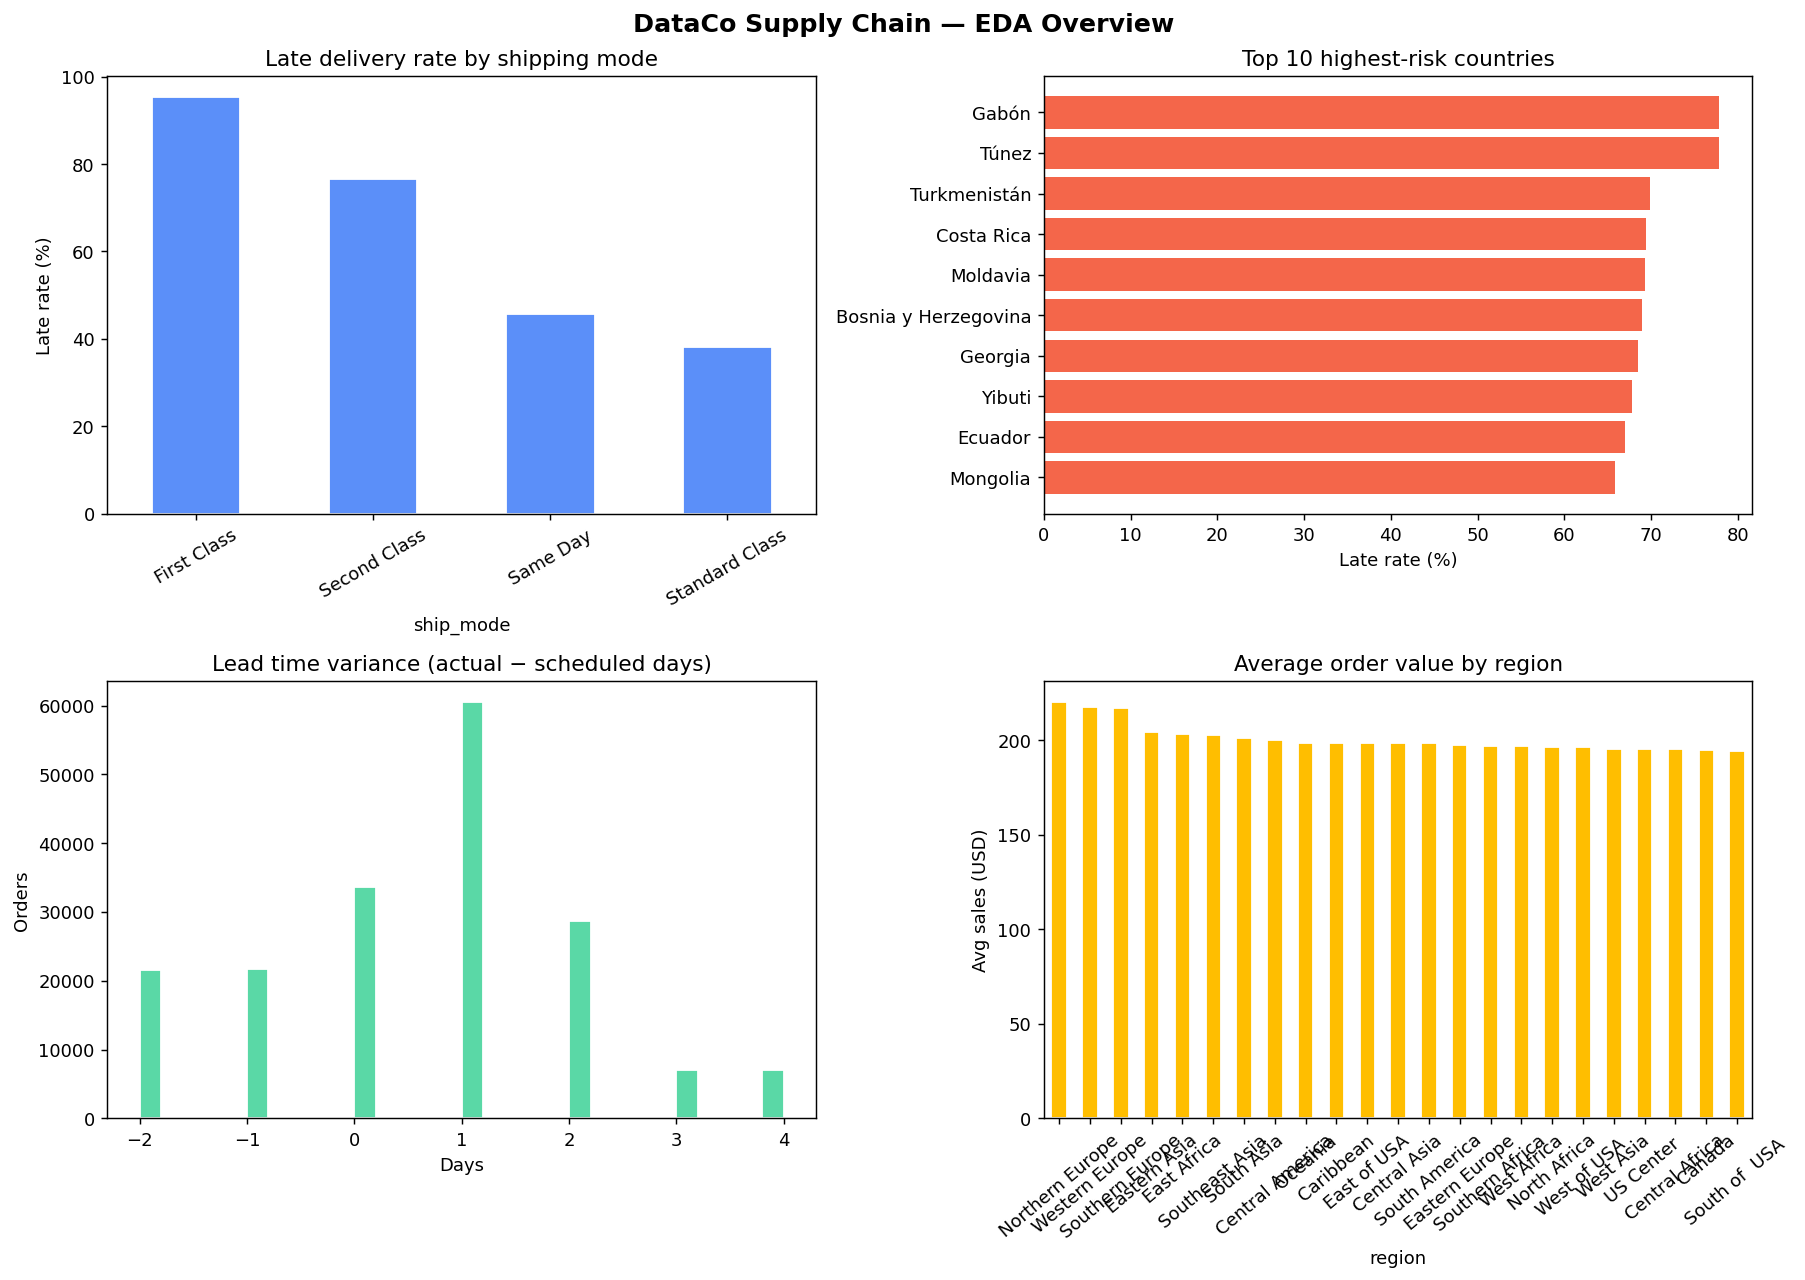

✅ Saved eda_overview.png


In [5]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams["figure.dpi"] = 130

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("DataCo Supply Chain — EDA Overview", fontsize=14, fontweight="bold")

# Chart 1: Late rate by shipping mode
mode = df.groupby("ship_mode")["late_risk"].mean().sort_values(ascending=False) * 100
mode.plot(kind="bar", ax=axes[0,0], color="#5B8FF9", edgecolor="white")
axes[0,0].set_title("Late delivery rate by shipping mode")
axes[0,0].set_ylabel("Late rate (%)")
axes[0,0].tick_params(axis="x", rotation=30)

# Chart 2: Top 10 riskiest countries
top10 = country_risk.sort_values("late_rate", ascending=False).head(10)
axes[0,1].barh(top10["country"], top10["late_rate"]*100, color="#F4664A")
axes[0,1].set_title("Top 10 highest-risk countries")
axes[0,1].set_xlabel("Late rate (%)")
axes[0,1].invert_yaxis()

# Chart 3: Lead time variance
axes[1,0].hist(df["lead_time_variance"].dropna(), bins=30,
               color="#5AD8A6", edgecolor="white")
axes[1,0].set_title("Lead time variance (actual − scheduled days)")
axes[1,0].set_xlabel("Days")
axes[1,0].set_ylabel("Orders")

# Chart 4: Avg sales by region
region_sales = df.groupby("region")["sales"].mean().sort_values(ascending=False)
region_sales.plot(kind="bar", ax=axes[1,1], color="#FFBE00", edgecolor="white")
axes[1,1].set_title("Average order value by region")
axes[1,1].set_ylabel("Avg sales (USD)")
axes[1,1].tick_params(axis="x", rotation=40)

plt.tight_layout()
plt.savefig("eda_overview.png", bbox_inches="tight")
plt.show()
print("✅ Saved eda_overview.png")

In [6]:
from sklearn.preprocessing import MinMaxScaler

country_risk["lead_var_norm"] = country_risk["avg_lead_var"].clip(lower=0)

scaler = MinMaxScaler()
risk_signals = ["late_rate", "lead_var_norm"]
country_risk[[s + "_scaled" for s in risk_signals]] = scaler.fit_transform(
    country_risk[risk_signals]
)

country_risk["risk_score"] = (
    country_risk["late_rate_scaled"]    * 0.60 +
    country_risk["lead_var_norm_scaled"] * 0.40
).round(4)

def assign_tier(score):
    if score >= 0.70:   return "Critical"
    elif score >= 0.45: return "High"
    elif score >= 0.20: return "Medium"
    else:               return "Low"

country_risk["risk_tier"] = country_risk["risk_score"].apply(assign_tier)

print("=== Risk Tier Distribution ===")
print(country_risk["risk_tier"].value_counts())
print("\n=== Top 15 Scored Countries ===")
print(country_risk[["country","total_orders","late_rate","risk_score","risk_tier"]]
      .sort_values("risk_score", ascending=False).head(15).to_string(index=False))

=== Risk Tier Distribution ===
risk_tier
Medium      60
High        46
Low         12
Critical     5
Name: count, dtype: int64

=== Top 15 Scored Countries ===
             country  total_orders  late_rate  risk_score risk_tier
               Gabón            45   0.777778      0.9116  Critical
            Moldavia            78   0.692308      0.8769  Critical
          Costa Rica            36   0.694444      0.8490  Critical
               Túnez            36   0.777778      0.8377  Critical
            Mongolia            79   0.658228      0.7889  Critical
        Turkmenistán            53   0.698113      0.6692      High
Bosnia y Herzegovina            45   0.688889      0.6588      High
          Mozambique           244   0.639344      0.6394      High
               Níger           106   0.650943      0.6375      High
             Georgia            92   0.684783      0.6323      High
              Yibuti            31   0.677419      0.6198      High
             Ecuador    

In [7]:
geo = df.groupby("country").agg(lat=("lat","mean"), lon=("lon","mean")).reset_index()
dominant_mode = df.groupby("country")["ship_mode"].agg(
    lambda x: x.value_counts().index[0]
).reset_index()
dominant_mode.columns = ["country", "dominant_ship_mode"]

country_risk = country_risk.merge(geo, on="country", how="left")
country_risk = country_risk.merge(dominant_mode, on="country", how="left")

country_risk.to_csv("country_risk_scored.csv", index=False)
print(f"✅ Saved country_risk_scored.csv — {len(country_risk)} countries")

✅ Saved country_risk_scored.csv — 123 countries


In [8]:
!pip install pycountry -q
import pycountry

# Step 1: Fuzzy match English names first
def get_iso3_fuzzy(name):
    try:
        return pycountry.countries.search_fuzzy(name)[0].alpha_3
    except:
        return None

country_risk["iso3"] = country_risk["country"].apply(get_iso3_fuzzy)

# Step 2: Complete Spanish → ISO3 dictionary (all 60 names)
spanish_fixes = {
    "Afganistán":                      "AFG",
    "Alemania":                        "DEU",
    "Arabia Saudí":                    "SAU",
    "Argelia":                         "DZA",
    "Azerbaiyán":                      "AZE",
    "Bielorrusia":                     "BLR",
    "Bosnia y Herzegovina":            "BIH",
    "Brasil":                          "BRA",
    "Bélgica":                         "BEL",
    "Camboya":                         "KHM",
    "Camerún":                         "CMR",
    "Corea del Sur":                   "KOR",
    "Costa de Marfil":                 "CIV",
    "Croacia":                         "HRV",
    "Egipto":                          "EGY",
    "España":                          "ESP",
    "Estados Unidos":                  "USA",
    "Filipinas":                       "PHL",
    "Finlandia":                       "FIN",
    "Francia":                         "FRA",
    "Guadalupe":                       "GLP",
    "Hungría":                         "HUN",
    "Irlanda":                         "IRL",
    "Japón":                           "JPN",
    "Jordania":                        "JOR",
    "Kazajistán":                      "KAZ",
    "Kenia":                           "KEN",
    "Kirguistán":                      "KGZ",
    "Libia":                           "LBY",
    "Lituania":                        "LTU",
    "Malasia":                         "MYS",
    "Marruecos":                       "MAR",
    "Martinica":                       "MTQ",
    "Moldavia":                        "MDA",
    "Myanmar (Birmania)":              "MMR",
    "Noruega":                         "NOR",
    "Nueva Zelanda":                   "NZL",
    "Papúa Nueva Guinea":              "PNG",
    "Países Bajos":                    "NLD",
    "Polonia":                         "POL",
    "Reino Unido":                     "GBR",
    "República Checa":                 "CZE",
    "República Democrática del Congo": "COD",
    "República Dominicana":            "DOM",
    "Ruanda":                          "RWA",
    "Rumania":                         "ROU",
    "Rusia":                           "RUS",
    "Sierra Leona":                    "SLE",
    "Singapur":                        "SGP",
    "Siria":                           "SYR",
    "SudAfrica":                       "ZAF",
    "Suecia":                          "SWE",
    "Suiza":                           "CHE",
    "Tailandia":                       "THA",
    "Trinidad y Tobago":               "TTO",
    "Turquía":                         "TUR",
    "Túnez":                           "TUN",
    "Ucrania":                         "UKR",
    "Yibuti":                          "DJI",
    "Zimbabue":                        "ZWE",
}

# Step 3: Apply fixes
for country, iso in spanish_fixes.items():
    country_risk.loc[country_risk["country"] == country, "iso3"] = iso

# Step 4: Verify
still_missing = country_risk[country_risk["iso3"].isna()]
print(f"✅ Matched: {country_risk['iso3'].notna().sum()}")
print(f"❌ Still unmatched: {len(still_missing)}")
if len(still_missing) > 0:
    print(still_missing["country"].tolist())

country_risk = country_risk.dropna(subset=["iso3"])
print(f"\n✅ Final country count ready for map: {len(country_risk)}")

✅ Matched: 123
❌ Still unmatched: 0

✅ Final country count ready for map: 123


In [13]:
import plotly.graph_objects as go
import plotly.express as px

tier_color_map = {
    "Critical": "#E24B4A",
    "High":     "#EF9F27",
    "Medium":   "#378ADD",
    "Low":      "#1D9E75"
}

country_risk["hover_text"] = country_risk.apply(lambda r: (
    f"<b>{r['country']}</b><br>"
    f"─────────────────<br>"
    f"Risk Tier: <b>{r['risk_tier']}</b><br>"
    f" Risk Score: <b>{r['risk_score']:.3f}</b><br>"
    f" Late Rate: <b>{r['late_rate']*100:.1f}%</b><br>"
    f" Total Orders: {int(r['total_orders']):,}<br>"
    f" Avg Lead Variance: {r['avg_lead_var']:.1f} days<br>"
    f" Dominant Ship Mode: {r['dominant_ship_mode']}"
), axis=1)

fig = px.choropleth(
    country_risk,
    locations          = "iso3",
    color              = "risk_tier",
    color_discrete_map = tier_color_map,
    category_orders    = {"risk_tier": ["Critical", "High", "Medium", "Low"]},
    hover_name         = "country",
    custom_data        = ["hover_text"],
    title              = "🌍 Global Supply Chain Risk Intelligence Map",
    projection         = "natural earth",
)

fig.update_traces(
    hovertemplate = "%{customdata[0]}<extra></extra>",
    marker_line_color = "white",
    marker_line_width = 0.5,
)

fig.update_layout(
    title = dict(
        text      = "🌍 Global Supply Chain Risk Intelligence Map",
        font_size = 20,
        x         = 0.5,
        xanchor   = "center",
        y         = 0.97,
    ),
    geo = dict(
        showframe      = False,
        showcoastlines = True,
        coastlinecolor = "#cccccc",
        showland       = True,
        landcolor      = "#f5f5f5",
        showocean      = True,
        oceancolor     = "#d4eaf7",
        showlakes      = True,
        lakecolor      = "#d4eaf7",
        showrivers     = True,
        rivercolor     = "#d4eaf7",
        bgcolor        = "#ffffff",
        projection_type = "natural earth",
    ),
    legend = dict(
        title_text      = "<b>Risk Tier</b>",
        orientation     = "v",
        x               = 0.01,
        y               = 0.5,
        bgcolor         = "rgba(255,255,255,0.85)",
        bordercolor     = "#dddddd",
        borderwidth     = 1,
        font_size       = 13,
    ),
    margin        = dict(l=0, r=0, t=50, b=0),
    height        = 600,
    paper_bgcolor = "white",
    plot_bgcolor  = "white",
    hoverlabel    = dict(
        bgcolor   = "black",
        font_size = 13,
        bordercolor = "#cccccc",
    ),
    annotations = [{
        "text": "Source: DataCo Smart Supply Chain Dataset | 180,519 orders | Mahek Manani",
        "x": 0.5, "y": -0.02,
        "xref": "paper", "yref": "paper",
        "showarrow": False,
        "font": dict(size=11, color="#888888"),
        "xanchor": "center",
    }]
)

# Supplier dots sized by order volume
fig.add_trace(go.Scattergeo(
    lat  = country_risk["lat"],
    lon  = country_risk["lon"],
    mode = "markers",
    marker = dict(
        size        = (country_risk["total_orders"] / country_risk["total_orders"].max() * 28 + 5).clip(5, 33),
        color       = country_risk["risk_tier"].map(tier_color_map),
        line        = dict(color="white", width=1),
        opacity     = 0.75,
        symbol      = "circle",
    ),
    text          = country_risk["hover_text"],
    hovertemplate = "%{text}<extra></extra>",
    name          = "Order volume",
    showlegend    = False,
))

fig.show()
fig.write_html("supply_chain_risk_map.html")
print("✅ Enhanced map saved!")

✅ Enhanced map saved!


In [14]:
from google.colab import files
files.download("supply_chain_risk_map.html")
files.download("country_risk_scored.csv")
files.download("eda_overview.png")
print("✅ All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded!
